In [14]:
import os
import sys
sys.path.insert(
    0, os.path.abspath('../../')
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tiktoken

from pathlib import Path
from datasets import load_dataset

## Load Embeddings & Labels

In [23]:
root_dir = Path("../../").resolve()
emb_save_dir = root_dir / "data/subj/embeddings/openai/text-embedding-3-small"
print(*os.listdir(emb_save_dir), sep='\n')

train.features.npy
train.labels.npy
test.features.npy
test.labels.npy


In [24]:
# load embeddings 
X_train = np.load(emb_save_dir / "train.features.npy")
y_train = np.load(emb_save_dir / "train.labels.npy")
X_test  = np.load(emb_save_dir / "test.features.npy")
y_test  = np.load(emb_save_dir / "test.labels.npy")

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8000, 1536), (8000,), (2000, 1536), (2000,))

## Load Text

In [25]:
ds = load_dataset("SetFit/subj", trust_remote_code=True)

Repo card metadata block was not found. Setting CardData to empty.


In [26]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 8000
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 2000
    })
})

In [27]:
train_data = ds['train'].to_pandas()
test_data = ds['test'].to_pandas()

In [28]:
encoding = tiktoken.encoding_for_model("gpt-4o")  # import tiktoken

In [29]:
%%time

train_data['num_tokens'] = [len(r) for r in encoding.encode_batch(train_data['text'])]
test_data['num_tokens'] = [len(r) for r in encoding.encode_batch(test_data['text'])]

CPU times: user 395 ms, sys: 102 ms, total: 497 ms
Wall time: 272 ms


In [30]:
train_data['split'] = 'train'
test_data['split'] = 'test'

data = pd.concat([train_data, test_data], axis=0, ignore_index=True)

from IPython.display import display
display(data);

,text,label,label_text,num_tokens,split
0,"the tucks have a secret , they 're immortal . ...",0,objective,13,train
1,this could be lizzy 's only chance to start a ...,0,objective,26,train
2,"the book tells of murray , the old scot patrio...",0,objective,30,train
3,check your brain and your secret agent decoder...,1,subjective,48,train
4,"naturally , he returns to his analyst dr . ben...",0,objective,45,train
...,...,...,...,...,...
9995,this being the offering of sexual favours to o...,0,objective,22,test
9996,"he lives his life in solitude , keeping his gi...",0,objective,40,test
9997,when reuben buys a black-market cure for his u...,0,objective,24,test
9998,"nicklas passes out , and the next day when he ...",0,objective,23,test


## Length

By split

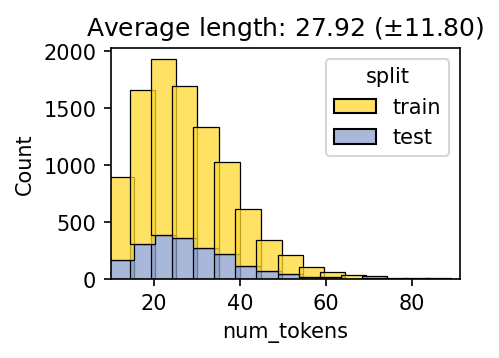

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2), dpi=150)
sns.histplot(data=data, x='num_tokens', hue='split', palette="Set2_r", alpha=.75, stat='count',
             edgecolor='k', shrink=1.2, bins=30, multiple='stack', ax=ax)
ax.set_title(
    f"Average length: {data['num_tokens'].mean():.2f} ($\pm${data['num_tokens'].std(ddof=1):.2f})"
)

lower_limit = data['num_tokens'].quantile(.001)
upper_limit = data['num_tokens'].quantile(.999)
ax.set_xlim(lower_limit, upper_limit)

plt.show(fig)

By label
- objective (0) data points seem to be longer that subjective (1) ones.

In [32]:
data.groupby('label')['num_tokens'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,5000.0,28.91,13.36,10.0,19.0,26.0,36.0,157.0
1,5000.0,26.93,9.90,10.0,19.0,26.0,34.0,65.0


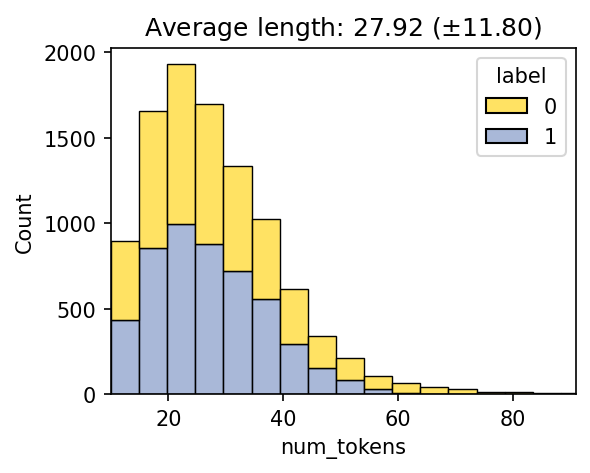

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3), dpi=150)
sns.histplot(data=data, x='num_tokens', hue='label', palette="Set2_r", alpha=.75, stat='count',
             edgecolor='k', shrink=1.0, bins=30, multiple='stack', ax=ax)
ax.set_title(
    f"Average length: {data['num_tokens'].mean():.2f} ($\pm${data['num_tokens'].std(ddof=1):.2f})"
)

lower_limit = data['num_tokens'].quantile(.001)
upper_limit = data['num_tokens'].quantile(.999)
ax.set_xlim(lower_limit, upper_limit)

plt.show(fig)

In [34]:
for i, row in data.iterrows():
    print(f"(i={i:>4}, y={row['label']}) {row['text']}")
    if i == 10:
        break

(i=   0, y=0) the tucks have a secret , they 're immortal . they
(i=   1, y=0) this could be lizzy 's only chance to start a new life and recreate the family she tragically lost as a child .
(i=   2, y=0) the book tells of murray , the old scot patriot , who has had his eyes torn out and his house taken away during the english invasion .
(i=   3, y=1) check your brain and your secret agent decoder ring at the door because you do n't want to think too much about what 's going on . the movie does has some entertainment value - how much depends on how well you like chris rock .
(i=   4, y=0) naturally , he returns to his analyst dr . ben sobel ( crystal ) for help and finds that sobel needs some serious help himself as he has inherited the family practice , as well as an excess stock of stress .
(i=   5, y=0) still suffering from her hangover , julie does n't realize that ellen is missing when the school bus leaves the cemetery .
(i=   6, y=0) several people are listening to keith 's plig

## Label Distribution

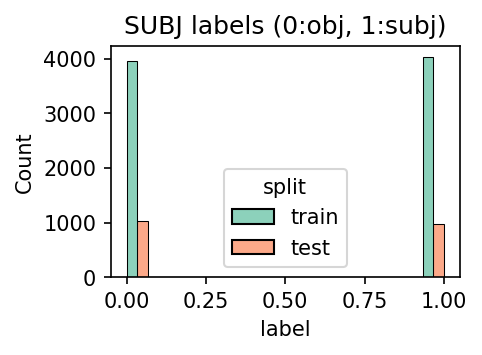

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2), dpi=150)
sns.histplot(data=data, x='label', hue='split', palette="Set2", alpha=.75,
             stat='count',
             edgecolor='k', shrink=1.0, bins='auto', multiple='dodge', ax=ax)
ax.set_title(
    f"SUBJ labels (0:obj, 1:subj)"
)

plt.show(fig)

## Diversity Metrics

In [40]:
from softprompt.metrics.diversity import (
    vocabulary_size,
    distinct_n,
    average_pairwise_similarity,
    average_pairwise_similarity_by_class,
    inter_sample_ngram_freq
)

In [41]:
texts = train_data['text'].to_list()
labels = train_data['label'].values
embeddings = X_train.copy()
assert len(texts) == embeddings.shape[0]
assert len(texts) == labels.shape[0]
print(len(texts))

8000


In [42]:
vocab_size = vocabulary_size(texts)
print(f"Vocab: {vocab_size:>7,}")

Vocab:  20,189


In [43]:
distinct_2 = distinct_n(texts, n=2)
print(f"Distinct-2: {distinct_2:.4f}")

Distinct-2: 0.5458


In [44]:
%%time
inter_sim, intra_sim = average_pairwise_similarity_by_class(
    embeddings, labels
)
print(f"Inter-class APS: {inter_sim:.4f}\n",
      f"Intra-class APS: {intra_sim:.4f}")

Inter-class APS: 0.1991
 Intra-class APS: 0.2520
CPU times: user 8.84 s, sys: 1.99 s, total: 10.8 s
Wall time: 644 ms


In [45]:
%%time
avg_ps = average_pairwise_similarity(embeddings)
print(f"Avg Pairwise Similarity: {avg_ps:.4f}")

Avg Pairwise Similarity: 0.2256
CPU times: user 9.84 s, sys: 1.63 s, total: 11.5 s
Wall time: 635 ms


## Classification Performance

train.features.npy
train.labels.npy
test.features.npy
test.labels.npy


In [27]:
from sklearn.linear_model import LogisticRegressionCV

def evaluate_lg(X_train: np.ndarray,
                y_train: np.ndarray,
                X_test: np.ndarray,
                y_test: np.ndarray,
                subsample_size: int = 1000,
                bootstrap: bool = True,  # sampling with replacement
                n_trials: int = 50) -> dict[str, tuple[float, float]]:

    assert X_train.shape[0] == len(y_train)

    train_acc_array = np.empty(n_trials)
    test_acc_array = np.empty_like(train_acc_array)
    
    original_idx = np.arange(X_train.shape[0])  # [0, 1, ..., len(X_train)]

    for i in range(n_trials):
        
        # get indices to use for training
        rng = np.random.default_rng(42+i)
        if bootstrap:
            use_idx = rng.choice(original_idx, size=subsample_size, replace=True)
        else:
            shuffled_idx = rng.permutation(original_idx)
            use_idx = shuffled_idx[:subsample_size]

        # fit model
        lg = LogisticRegressionCV(Cs=10, cv=5, penalty='l2',
                                  solver='lbfgs', max_iter=1000, n_jobs=8,
                                  random_state=42+i)
        lg.fit(X_train[use_idx], y_train[use_idx]);

        # evaluate
        train_acc_array[i] = lg.score(X_train[use_idx], y_train[use_idx])
        test_acc_array[i] = lg.score(X_test, y_test)

    return {
        'train_accuracy': (train_acc_array.mean(), train_acc_array.std(ddof=1)),
        'test_accuracy': (test_acc_array.mean(), test_acc_array.std(ddof=1)),
    }

In [28]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [29]:
size_to_acc = {}

ratios = (0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 1.00)
subsample_sizes = [int(len(X_train) * r) for r in ratios]
for i, subsample_size in enumerate(subsample_sizes):

    print(f">> Sample size: {subsample_size:>6,} (r={ratios[i]:.2f})")

    eval_result = evaluate_lg(
        X_train,
        (y_train > 0.5).astype(int),
        X_test,
        (y_test > 0.5).astype(int),
        subsample_size=subsample_size,
        bootstrap=True,
        n_trials=50,
    )

    train_acc, test_acc = \
        eval_result['train_accuracy'], eval_result['test_accuracy']

    size_to_acc[subsample_size] = eval_result

    print("\t Train acc = {:.4f} ({:.4f})".format(*train_acc))
    print("\t  Test acc = {:.4f} ({:.4f})".format(*test_acc))

>> Sample size:     80 (r=0.01)
	 Train acc = 0.9910 (0.0141)
	  Test acc = 0.9252 (0.0109)
>> Sample size:    400 (r=0.05)
	 Train acc = 0.9886 (0.0128)
	  Test acc = 0.9475 (0.0047)
>> Sample size:    800 (r=0.10)
	 Train acc = 0.9929 (0.0115)
	  Test acc = 0.9523 (0.0034)
>> Sample size:  2,000 (r=0.25)
	 Train acc = 0.9963 (0.0042)
	  Test acc = 0.9574 (0.0031)
>> Sample size:  4,000 (r=0.50)
	 Train acc = 0.9952 (0.0032)
	  Test acc = 0.9598 (0.0035)
>> Sample size:  6,000 (r=0.75)
	 Train acc = 0.9936 (0.0026)
	  Test acc = 0.9613 (0.0031)
>> Sample size:  8,000 (r=1.00)
	 Train acc = 0.9928 (0.0026)
	  Test acc = 0.9624 (0.0028)
